In [1]:
!pip install shap
!pip install lime
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))
     

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

     ---------------------------------------- 0.0/275.7 kB ? eta -:--:--
     - -------------------------------------- 10.2/275.7 kB ? eta -:--:--
     - -------------------------------------- 10.2/275.7 kB ? eta -:--:--
     - -------------------------------------- 10.2/275.7 kB ? eta -:--:--
     ---- -------------------------------- 30.7/275.7 kB 119.1 kB/s eta 0:00:03
     ----- ------------------------------- 41.0/275.7 kB 140.3 kB/s eta 0:00:02
     -------- ---------------------------- 61.4/275.7 kB 217.9 kB/s eta 0:00:01
     -------- ---------------------------- 61.4/275.7 kB 217.9 kB/s eta 0:00:01
     --------- --------------------------- 71.7/275.7 kB 187.3 kB/s eta 0:00:02
     --------- --------------------------- 71.7/275.7 kB 187.3 kB/s eta 0:00:02
     -------------- --------------------- 112.6/275.7 kB 242.7 kB/s eta 0:00:01
     -------------- --------------------- 112.6/275.7 kB 242.7 kB/s eta 0:00:01
     -------------- --------------------- 112.6/275.7 kB 242.7 kB

**INTRODUCTION**

This experimental work aims to implement a machine learning model to predict bias in the Adult Income Dataset obtained from Kaggle https://www.kaggle.com/datasets/wenruliu/adult-income-dataset. The model predicts which specific gender, age bracket, Workclass, occupation, education, or race (either white or black) earns <=50K or >50K annually. The dataset contains demographic information about individuals and their income. The model serves as a valuable tool to identify potential biases in income distribution and provides insights into ways to address income inequality.

**PACKAGES IMPORT**

In [2]:
import shap 
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn import svm, metrics
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score
sns.set_theme(style = 'whitegrid')

Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)


**LOADING THE DATA**

In [3]:
adult = pd.read_csv("../Dataset/adult.csv")
adult.head()

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K


**DATA EXPLORATION AND VISUALIZATION**

In [4]:
adult.dropna(inplace = True)

In [5]:
adult.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   age              48842 non-null  int64 
 1   workclass        48842 non-null  object
 2   fnlwgt           48842 non-null  int64 
 3   education        48842 non-null  object
 4   educational-num  48842 non-null  int64 
 5   marital-status   48842 non-null  object
 6   occupation       48842 non-null  object
 7   relationship     48842 non-null  object
 8   race             48842 non-null  object
 9   gender           48842 non-null  object
 10  capital-gain     48842 non-null  int64 
 11  capital-loss     48842 non-null  int64 
 12  hours-per-week   48842 non-null  int64 
 13  native-country   48842 non-null  object
 14  income           48842 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.6+ MB


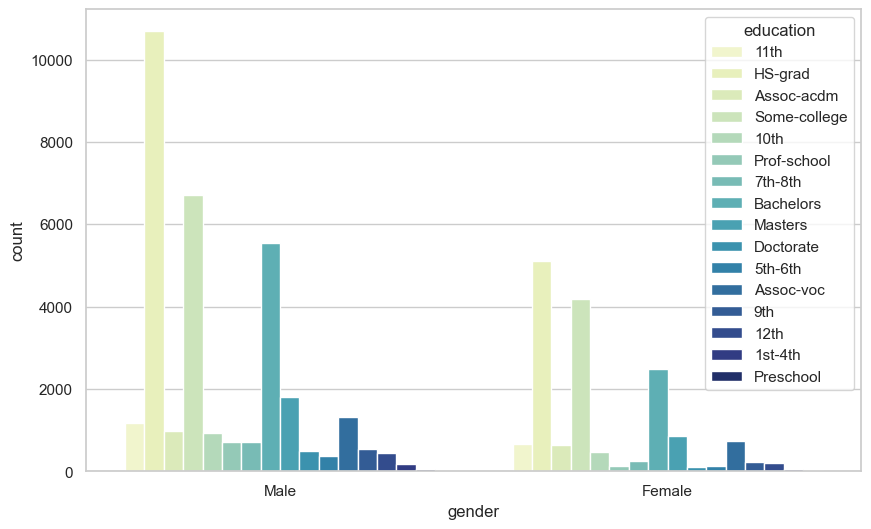

In [6]:
plt.figure(figsize = (10, 6))
sns.countplot(x = 'gender', hue = 'education', data = adult, palette = 'YlGnBu')
plt.show()

### OBSERVATION:
- Here the males have more educational qualifications than the females

In [2]:
plt.figure(figsize = (10, 6))
sns.countplot(x = 'gender', data = adult, hue = 'workclass')

NameError: name 'plt' is not defined

### OBSERVATION:
- Here there is an over representation of males in the private sector over the females
- More males are self employed as compared to females

<Axes: xlabel='income', ylabel='fnlwgt'>

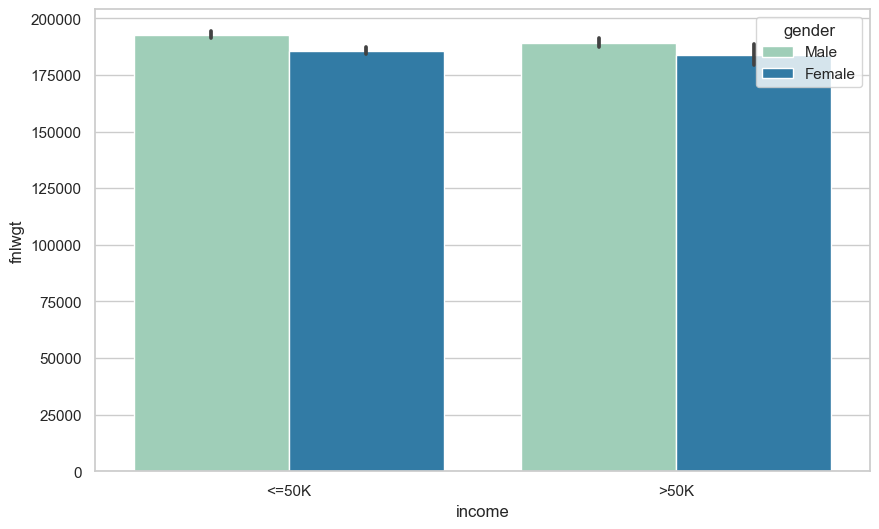

In [8]:
plt.figure(figsize = (10, 6))
sns.barplot(data = adult, y = 'fnlwgt', x = 'income', hue = 'gender', palette = 'YlGnBu')

### OBSERVATION:
- Here the final weight of men is more than the final weight of women in both income groups

In [9]:
adult["gender"].replace({'Male': 1, 'Female': 0}, inplace=True)
adult["education"].replace({'Preschool': 0,
                            '1st - 4th': 1,
                            '5th - 6th': 2,
                            '7th - 8th': 3,
                            '9th': 4,
                            '10th': 5,
                            '11th': 6,
                            '12th': 7,
                            'HS-grad': 8,
                            'Some-college': 9,
                           'Bachelors': 10,
                           'Masters': 11,
                           'Doctorate': 12,
                           'Prof-school': 13}, inplace=True)
adult["income"].replace({'<=50K': 0, '>50K': 1}, inplace=True)
adult["workclass"].replace({'?': 0, 
                            'Never-worked': 1, 
                            'Without-pay': 2, 
                            'Self-emp-not-inc': 3,
                           'Self-emp-inc': 4,
                           'Private': 5,
                           'Local-gov': 6,
                           'State-gov': 7,
                           'Federal-gov': 8}, inplace=True)
adult["race"].replace({'Black': 0, 
                            'White': 1, 
                            'Asian-Pac-Islander': 2, 
                            'Other': 3,
                      'Amer-Indian-Eskimo': 4}, inplace=True)
adult = pd.get_dummies(adult, columns=['occupation'])

adult.head()

,age,workclass,fnlwgt,education,educational-num,marital-status,relationship,race,gender,capital-gain,...,occupation_Farming-fishing,occupation_Handlers-cleaners,occupation_Machine-op-inspct,occupation_Other-service,occupation_Priv-house-serv,occupation_Prof-specialty,occupation_Protective-serv,occupation_Sales,occupation_Tech-support,occupation_Transport-moving
0,25,5,226802,6,7,Never-married,Own-child,0,1,0,...,0,0,1,0,0,0,0,0,0,0
1,38,5,89814,8,9,Married-civ-spouse,Husband,1,1,0,...,1,0,0,0,0,0,0,0,0,0
2,28,6,336951,Assoc-acdm,12,Married-civ-spouse,Husband,1,1,0,...,0,0,0,0,0,0,1,0,0,0
3,44,5,160323,9,10,Married-civ-spouse,Husband,0,1,7688,...,0,0,1,0,0,0,0,0,0,0
4,18,0,103497,9,10,Never-married,Own-child,1,0,0,...,0,0,0,0,0,0,0,0,0,0


The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.


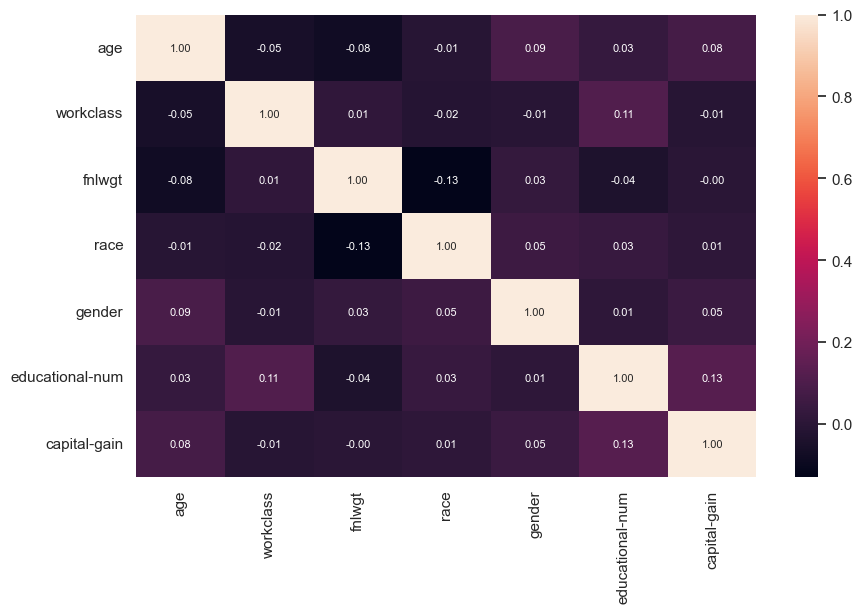

In [10]:
plt.figure(figsize = (10, 6))
corr_matrix = adult[['age', 'workclass','fnlwgt', 'education', 'race', 'gender', 
                     'educational-num', 'capital-gain']].corr()
sns.heatmap(corr_matrix, annot=True, fmt = '.2f', annot_kws = {'size': 8}, vmax= 1)
plt.show()

In [11]:
x=adult.drop(columns=['marital-status','relationship', 'education', 'native-country'],axis=1)
y=adult["income"]
x.head()

,age,workclass,fnlwgt,educational-num,race,gender,capital-gain,capital-loss,hours-per-week,income,...,occupation_Farming-fishing,occupation_Handlers-cleaners,occupation_Machine-op-inspct,occupation_Other-service,occupation_Priv-house-serv,occupation_Prof-specialty,occupation_Protective-serv,occupation_Sales,occupation_Tech-support,occupation_Transport-moving
0,25,5,226802,7,0,1,0,0,40,0,...,0,0,1,0,0,0,0,0,0,0
1,38,5,89814,9,1,1,0,0,50,0,...,1,0,0,0,0,0,0,0,0,0
2,28,6,336951,12,1,1,0,0,40,1,...,0,0,0,0,0,0,1,0,0,0
3,44,5,160323,10,0,1,7688,0,40,1,...,0,0,1,0,0,0,0,0,0,0
4,18,0,103497,10,1,0,0,0,30,0,...,0,0,0,0,0,0,0,0,0,0


In [12]:
x.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 25 columns):
 #   Column                        Non-Null Count  Dtype
---  ------                        --------------  -----
 0   age                           48842 non-null  int64
 1   workclass                     48842 non-null  int64
 2   fnlwgt                        48842 non-null  int64
 3   educational-num               48842 non-null  int64
 4   race                          48842 non-null  int64
 5   gender                        48842 non-null  int64
 6   capital-gain                  48842 non-null  int64
 7   capital-loss                  48842 non-null  int64
 8   hours-per-week                48842 non-null  int64
 9   income                        48842 non-null  int64
 10  occupation_?                  48842 non-null  uint8
 11  occupation_Adm-clerical       48842 non-null  uint8
 12  occupation_Armed-Forces       48842 non-null  uint8
 13  occupation_Craft-repair       4

### Apply Model

In [13]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3, stratify=y, random_state=2)
print(x.shape,x_train.shape,x_test.shape)

(48842, 25) (34189, 25) (14653, 25)


In [14]:
x_train['gender'].value_counts()

1    22761
0    11428
Name: gender, dtype: int64

## Naive_bayes

In [15]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import precision_score
from sklearn.metrics import confusion_matrix

nb = GaussianNB()
nb.fit(x_train, y_train)
y_pred = nb.predict(x_test)

print("Naive Bayes train score : {:.4f}".format(nb.score(x_train, y_train)))
print("Naive Bayes test score : {:.4f}".format(nb.score(x_test, y_test)))

Naive Bayes train score : 0.7968
Naive Bayes test score : 0.7947


In [16]:
acc_score = accuracy_score(y_test, y_pred) * 100
prec_score = precision_score(y_test, y_pred) * 100
print(f'Model accuracy is: {round(acc_score, 2)}')
print(f'Model Precision score is {round(prec_score,2 )}')

Model accuracy is: 79.47
Model Precision score is 65.0


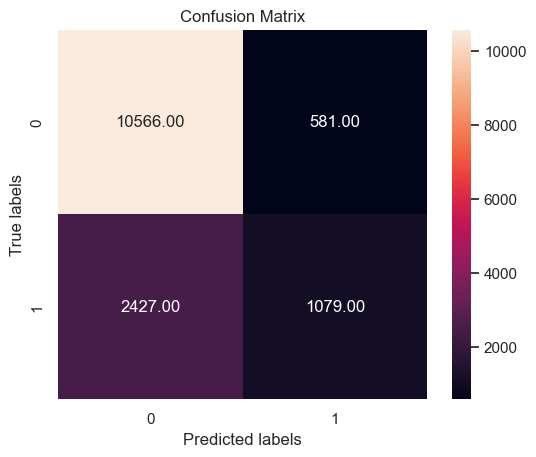

In [17]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot = True, fmt = '.2f', square = True)
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.title('Confusion Matrix')
plt.show()

In [18]:
import lime.lime_tabular

In [19]:
explainer = lime.lime_tabular.LimeTabularExplainer(np.array(x_train),
                                                feature_names=x_train.columns,
                                                  verbose=True, mode='classification')
explainer

In [20]:
explanation = explainer.explain_instance(x_test.iloc[0], nb.predict_proba)
explanation.show_in_notebook(show_table=True)

Intercept 1.7255031300879837
Prediction_local [0.02473782]
Right: 0.0264353815772058


X does not have valid feature names, but GaussianNB was fitted with feature names


In [21]:
explanation.as_list()

[('capital-gain <= 0.00', -0.8669543317246218),
 ('capital-loss <= 0.00', -0.8540546881108186),
 ('occupation_Priv-house-serv <= 0.00', 0.011296071371425144),
 ('occupation_Machine-op-inspct <= 0.00', 0.010868800167050179),
 ('age > 48.00', 0.01033398433744893),
 ('hours-per-week <= 40.00', -0.009434103215829055),
 ('occupation_Protective-serv <= 0.00', -0.009410889487812749),
 ('educational-num > 12.00', 0.007662941103915941),
 ('occupation_Farming-fishing <= 0.00', -0.007314103366327793),
 ('occupation_Tech-support <= 0.00', 0.006241011940756544)]

In [22]:
edited_x=adult.drop(columns=['marital-status','relationship', 'education', 'native-country', 'gender', 'age', 'race'],axis=1)
edited_y=adult["income"]
edited_x.head()

,workclass,fnlwgt,educational-num,capital-gain,capital-loss,hours-per-week,income,occupation_?,occupation_Adm-clerical,occupation_Armed-Forces,...,occupation_Farming-fishing,occupation_Handlers-cleaners,occupation_Machine-op-inspct,occupation_Other-service,occupation_Priv-house-serv,occupation_Prof-specialty,occupation_Protective-serv,occupation_Sales,occupation_Tech-support,occupation_Transport-moving
0,5,226802,7,0,0,40,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
1,5,89814,9,0,0,50,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
2,6,336951,12,0,0,40,1,0,0,0,...,0,0,0,0,0,0,1,0,0,0
3,5,160323,10,7688,0,40,1,0,0,0,...,0,0,1,0,0,0,0,0,0,0
4,0,103497,10,0,0,30,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0


In [23]:
edited_x_train,edited_x_test,edited_y_train,edited_y_test=train_test_split(edited_x,edited_y,test_size=0.3, stratify=y, random_state=2)
print(edited_x.shape,edited_x_train.shape,edited_x_test.shape)

(48842, 22) (34189, 22) (14653, 22)


In [24]:
from sklearn.naive_bayes import GaussianNB

nb = GaussianNB()
edited_nb = nb.fit(edited_x_train, edited_y_train)
edited_y_pred = edited_nb.predict(edited_x_test)

print("Naive Bayes train score : {:.4f}".format(nb.score(edited_x_train, edited_y_train)))
print("Naive Bayes test score : {:.4f}".format(nb.score(edited_x_test, edited_y_test)))

Naive Bayes train score : 0.7959
Naive Bayes test score : 0.7940


In [25]:
edited_acc_score = accuracy_score(edited_y_test, edited_y_pred) * 100
edited_prec_score = precision_score(edited_y_test, edited_y_pred) * 100
print(f'Model accuracy is: {round(edited_acc_score, 2)}')
print(f'Model Precision score is {round(edited_prec_score,2 )}')

Model accuracy is: 79.4
Model Precision score is 64.68


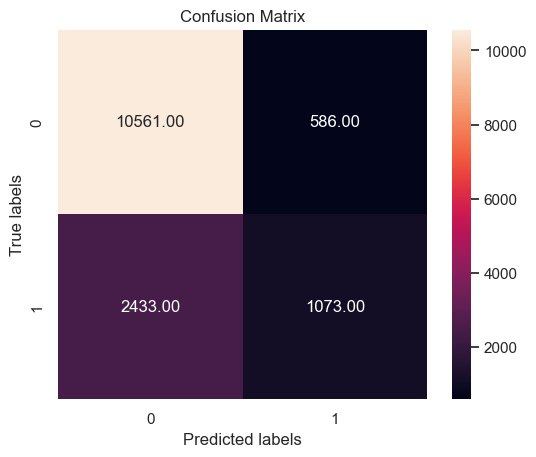

In [26]:
edited_cm = confusion_matrix(edited_y_test, edited_y_pred)
sns.heatmap(edited_cm, annot = True, fmt = '.2f', square = True)
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.title('Confusion Matrix')
plt.show()

In [27]:
explainer_2 = lime.lime_tabular.LimeTabularExplainer(np.array(edited_x_train),
                                                feature_names=edited_x_train.columns,
                                                  verbose=True, mode='classification')
explainer_2

In [28]:
explanation = explainer_2.explain_instance(edited_x_test.iloc[0], edited_nb.predict_proba)
explanation.show_in_notebook(show_table=True)

Intercept 1.7586887054970437
Prediction_local [0.01561708]
Right: 0.015285725510548609


X does not have valid feature names, but GaussianNB was fitted with feature names


In [29]:
explanation.as_list()

[('capital-gain <= 0.00', -0.8734074192581737),
 ('capital-loss <= 0.00', -0.8678586815549576),
 ('occupation_Priv-house-serv <= 0.00', 0.010114681113012565),
 ('hours-per-week <= 40.00', -0.010101497330643822),
 ('educational-num > 12.00', 0.009143111796321808),
 ('occupation_Handlers-cleaners <= 0.00', 0.008598897085749423),
 ('occupation_Transport-moving <= 0.00', -0.006033207333623168),
 ('occupation_Tech-support <= 0.00', -0.005645014640012597),
 ('workclass <= 5.00', -0.004536617950577475),
 ('occupation_? <= 0.00', -0.0033458727335121704)]